In [1]:
import copy
import pandas as pd
import numpy as np
from tqdm import tqdm
from ray import tune
import matplotlib.pyplot as plt
import pytagi.metric as metric
from pytagi import Normalizer as normalizer
from canari import (
    DataProcess,
    Model,
    ModelAssemble,
    Optimizer,
    plot_data,
    plot_prediction,
    plot_states,
)
from canari.component import LocalTrend, LstmNetwork, WhiteNoise

/opt/miniconda3/envs/canari/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-10-05 16:38:09,415	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-10-05 16:38:09,631	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
/Users/vuongdai/GitHub/canari/src/canari/data_visualization.py:394: SyntaxWarning: invalid escape sequence '\p'
  [r"$\mu$", f"$\pm{num_std}\sigma$"], loc=legend_location, ncol=2
/Users/vuongdai/GitHub/canari/src/canari/data_visualization.py:394: SyntaxWarning: invalid escape sequence '\s'
  [r"$\mu$", f"$\pm{num_std}\sigma$"], loc=legend_location, ncol=2
/Users/vuongdai/GitHub/canari/src/canari

In [2]:
# # Read data
data_file = "/Users/vuongdai/Desktop/backup_canari/data/icold_2022.csv"
df_raw = pd.read_csv(data_file, delimiter=",", header=0,
                     names=["datetime","cb2","cb3","waterlevel","temp_a","temp_b"],
                     usecols=["datetime","cb2","waterlevel"],
                     index_col="datetime", parse_dates=True)

# Resample
df_raw = df_raw.loc['2000-01-30':'2012-12-31']
df = df_raw.resample("W").last()

# Data pre-processing
output_col = [0]

In [3]:
# 
NUM_EPOCH = 50
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.1
OUTPUT_COL = [0] # Target

# seed
rng = np.random.default_rng(1)
seed = rng.integers(0, 1000)      
# seed = 1   

In [4]:
def build_data(covar_num_lag):
    df_lagged = DataProcess.add_lagged_columns(df, [0, covar_num_lag])
    data_processor = DataProcess(
        data=df_lagged,
        time_covariates=["week_of_year"],
        train_split=TRAIN_SPLIT,
        validation_split=VAL_SPLIT,
        output_col=output_col,
    )
    num_features = covar_num_lag + 3

    return data_processor, num_features

In [5]:
# data_processor, num_features = build_data(2)
# data_processor.data.head()

In [5]:
def model_with_parameters(param):
    (
        data_processor,
        num_features,
    ) = build_data(param["covar_num_lag"])

    train_data, validation_data, test_data, _ = data_processor.get_splits()

    # Target model
    model = Model(
        LstmNetwork(
            # look_back_len=param["target_look_back_len"],
            look_back_len=1,
            num_features=num_features,
            num_layer=1,
            num_hidden_unit=50,
            manual_seed=seed,
            smoother=False,
        ),
        WhiteNoise(std_error=param["target_sigma_v"]),
    )
    # 
    validation_obs = data_processor.get_data("validation").flatten()

    mu_validation_preds_optim = None
    std_validation_preds_optim = None
    mu_test_preds_optim = None
    std_test_preds_optim = None
    num_test = len(test_data["y"])
    num_val = len(validation_data["y"])
    
    for epoch in range(NUM_EPOCH):
        (mu_validation_preds, std_validation_preds, states) = model.lstm_train(
            train_data=train_data,
            validation_data=validation_data,
        )

        # Validation
        # Tartget predictions
        mu_validation_preds = normalizer.unstandardize(
            mu_validation_preds,
            data_processor.scale_const_mean[output_col],
            data_processor.scale_const_std[output_col],
        )
        std_validation_preds = normalizer.unstandardize_std(
            std_validation_preds,
            data_processor.scale_const_std[output_col],
        )

        mse = metric.mse(mu_validation_preds, validation_obs)
        validation_log_lik = metric.log_likelihood(
            prediction=mu_validation_preds,
            observation=validation_obs,
            std=std_validation_preds,
        )

        # Early-stopping on the validation set
        model.early_stopping(
            evaluate_metric=-validation_log_lik,
            current_epoch=epoch,
            max_epoch=NUM_EPOCH,
        )

        # Metric used by the Optimizer
        model.metric_optim = model.early_stop_metric

        if epoch == model.optimal_epoch:
            mu_validation_preds_optim = mu_validation_preds
            std_validation_preds_optim = std_validation_preds

        if model.stop_training:
            break

    return (
        model,
        data_processor,
        mu_validation_preds_optim,
        std_validation_preds_optim,
        )


In [7]:
# # Hyperparameter optimization with TPE sampling
param_space = {
    # "target_look_back_len": [1, 52],
    "target_sigma_v": tune.loguniform(1e-2, 2e-1),
    "covar_num_lag": [0, 26], 
}

model_optimizer = Optimizer(
    model=model_with_parameters,
    param=param_space,
    num_optimization_trial=80,
    num_startup_trials=30,
    mode="min",
    max_concurrent=6,
)
model_optimizer.optimize()
param_optim = model_optimizer.get_best_param()

#  1/80 - Metric: 246.892 - Parameter: {'target_sigma_v': 0.05232172125938423, 'covar_num_lag': 9}
#  2/80 - Metric: 160.804 - Parameter: {'target_sigma_v': 0.02474961880342847, 'covar_num_lag': 9}
#  3/80 - Metric: 256.020 - Parameter: {'target_sigma_v': 0.06480420288857536, 'covar_num_lag': 17}
#  4/80 - Metric: 313.201 - Parameter: {'target_sigma_v': 0.013208981565745686, 'covar_num_lag': 15}
#  5/80 - Metric: 125.319 - Parameter: {'target_sigma_v': 0.19520038842716786, 'covar_num_lag': 16}
#  6/80 - Metric: 262.014 - Parameter: {'target_sigma_v': 0.03020889950624477, 'covar_num_lag': 25}
#  7/80 - Metric: 157.440 - Parameter: {'target_sigma_v': 0.1251923273217232, 'covar_num_lag': 20}
#  8/80 - Metric: 139.174 - Parameter: {'target_sigma_v': 0.10934373455654046, 'covar_num_lag': 2}
#  9/80 - Metric: 200.594 - Parameter: {'target_sigma_v': 0.08353186554011387, 'covar_num_lag': 4}
# 10/80 - Metric: 310.232 - Parameter: {'target_sigma_v': 0.03981291344833251, 'covar_num_lag': 13}
# 11

2026-10-01 11:05:01,670	ERROR tune_controller.py:1332 -- Trial task failed for trial objective_714702dc
Traceback (most recent call last):
  File "/opt/miniconda3/envs/canari/lib/python3.12/site-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
             ^^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/canari/lib/python3.12/site-packages/ray/_private/auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/canari/lib/python3.12/site-packages/ray/_private/client_mode_hook.py", line 110, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/canari/lib/python3.12/site-packages/ray/_private/worker.py", line 2968, in get
    values, debugger_breakpoint = worker.get_objects(
                                  ^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/canari/lib/python3.12/site-packages/ray/_

# 14/80 - Metric: 260.518 - Parameter: {'target_sigma_v': 0.04651091701637554, 'covar_num_lag': 5}
# 15/80 - Metric: 137.995 - Parameter: {'target_sigma_v': 0.12281709642621955, 'covar_num_lag': 9}


2026-10-01 11:05:11,251	ERROR tune_controller.py:1332 -- Trial task failed for trial objective_2542feb0
Traceback (most recent call last):
  File "/opt/miniconda3/envs/canari/lib/python3.12/site-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
             ^^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/canari/lib/python3.12/site-packages/ray/_private/auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/canari/lib/python3.12/site-packages/ray/_private/client_mode_hook.py", line 110, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/canari/lib/python3.12/site-packages/ray/_private/worker.py", line 2968, in get
    values, debugger_breakpoint = worker.get_objects(
                                  ^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/canari/lib/python3.12/site-packages/ray/_

# 16/80 - Metric: 273.664 - Parameter: {'target_sigma_v': 0.028475827789929308, 'covar_num_lag': 22}
# 17/80 - Metric: 290.527 - Parameter: {'target_sigma_v': 0.028797090077723214, 'covar_num_lag': 22}
# 18/80 - Metric: 129.540 - Parameter: {'target_sigma_v': 0.10952178360209064, 'covar_num_lag': 15}
# 19/80 - Metric: 223.487 - Parameter: {'target_sigma_v': 0.07309186609040451, 'covar_num_lag': 21}
# 20/80 - Metric: 246.454 - Parameter: {'target_sigma_v': 0.062222356886884364, 'covar_num_lag': 18}
# 21/80 - Metric: 135.916 - Parameter: {'target_sigma_v': 0.1279930489233429, 'covar_num_lag': 4}
# 22/80 - Metric: 410.441 - Parameter: {'target_sigma_v': 0.019011770686869874, 'covar_num_lag': 2}
# 23/80 - Metric: 141.824 - Parameter: {'target_sigma_v': 0.12066878380297344, 'covar_num_lag': 4}
# 24/80 - Metric: 319.144 - Parameter: {'target_sigma_v': 0.011863538630942558, 'covar_num_lag': 15}
# 25/80 - Metric: 322.997 - Parameter: {'target_sigma_v': 0.06147636154990898, 'covar_num_lag': 24}

2026-10-01 11:08:03,374	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/Users/vuongdai/ray_results/objective_2026-10-01_11-04-20' in 0.0279s.
2026-10-01 11:08:03,376	ERROR tune.py:1035 -- Trials did not complete: [objective_714702dc, objective_2542feb0]


# 78/80 - Metric: 114.838 - Parameter: {'target_sigma_v': 0.19897630193924887, 'covar_num_lag': 4}
-----
Optimal parameters at trial #59. Best metric: 112.4293. Best print metric: None. Best param: {'target_sigma_v': 0.19963906684289834, 'covar_num_lag': 0}.
-----


In [6]:
param_optim = {'target_sigma_v': 0.19963906684289834, 'covar_num_lag': 0}

In [7]:
(   
    model,
    data_processor,
    mu_validation_preds_optim,
    std_validation_preds_optim,
) = model_with_parameters(param_optim)

In [8]:
# Test set
model.set_memory(time_step=data_processor.test_start - 1)

# Tartget predictions
_,_,test_data,_ = data_processor.get_splits()
mu_test_preds, std_test_preds,_ = model.forecast(data=test_data)

mu_test_preds = normalizer.unstandardize(
    mu_test_preds,
    data_processor.scale_const_mean[output_col],
    data_processor.scale_const_std[output_col],
)
std_test_preds = normalizer.unstandardize_std(
    std_test_preds,
    data_processor.scale_const_std[output_col],
)

In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

mpl.rcParams.update({
    # Use LaTeX for text rendering — fonts will match your Beamer theme exactly
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{lmodern}",

    # Font sizes: Beamer default body is 11pt
    "font.size": 22,
    "axes.titlesize": 22,
    "axes.labelsize": 22,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 22,

    # Thin lines look better on slides
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "lines.linewidth": 1.5,

    # No right/top spines (cleaner on slides)
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [10]:
print(f"Seed            : {seed}")
print(f"Optimal parameters            : {param_optim}")

Seed            : 473
Optimal parameters            : {'target_sigma_v': 0.19963906684289834, 'covar_num_lag': 0}


In [11]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

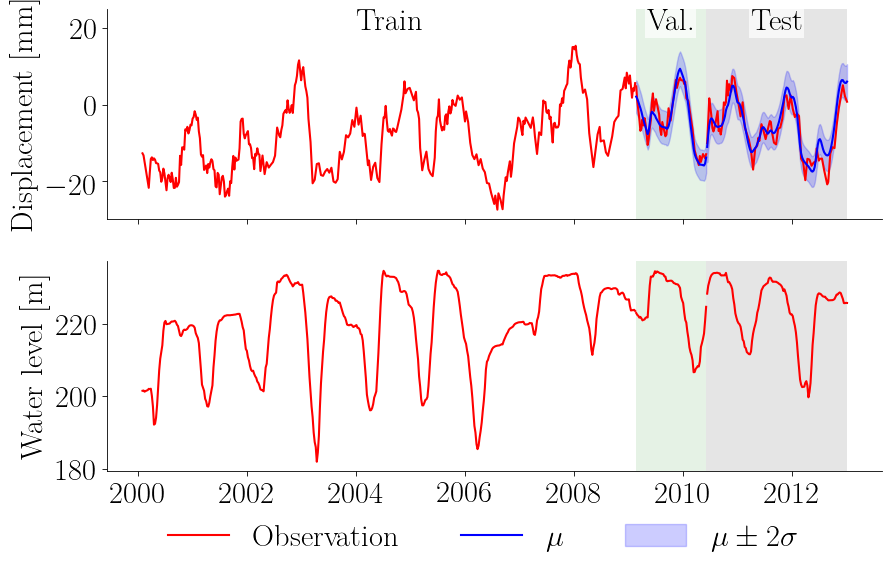

In [12]:

# --- Split boundaries on the x-axis ---
time = data_processor.data.index
t_start     = time[0]
t_train_end = time[data_processor.train_end - 1]       # last train point
t_val_end   = time[data_processor.validation_end - 1]  # last validation point
t_end       = time[-1]

splits = {
    "Train":      (t_start, t_train_end),
    "Val.": (t_train_end, t_val_end),
    "Test":       (t_val_end, t_end),
}

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# ===================== Subplot 1: Target model =====================
ax = axes[0]
plt.sca(ax)
plot_data(
    data_processor=data_processor,
    standardization=False,
    plot_column=output_col,
    plot_nan=False,
    validation_label="Observation",
)
plot_prediction(
    data_processor=data_processor,
    mean_validation_pred=mu_validation_preds_optim,
    std_validation_pred=std_validation_preds_optim,
    validation_label=[r"$\mu$", r"$\mu \pm 2\sigma$"],
    color="blue",
    num_std=2,
)
plot_prediction(
    data_processor=data_processor,
    mean_test_pred=mu_test_preds,
    std_test_pred=std_test_preds,
    color="blue",
    num_std=2,
)

trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
for label, (a, b) in splits.items():
    mid = a + (b - a) / 2
    ax.text(mid, 1, label, transform=trans,
            ha="center", va="top", fontsize=22,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1))

# ax.legend(loc="upper center", bbox_to_anchor=(0.12, 1.2), ncol=3, frameon=False)
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.grid(False, which="both", axis="x")
ax.set_ylim(-30, 25)
ax.set_ylabel("Displacement [mm]")

# # ===================== Subplot 2: Univariate model =====================
# ax = axes[1]
# plt.sca(ax)
# plot_data(
#     data_processor=data_processor,
#     standardization=False,
#     plot_column=output_col,
#     plot_nan=False,
#     validation_label="obs.",
# )
# plot_prediction(
#     data_processor=data_processor,
#     mean_validation_pred=mu_validation_preds_optim_univariate,
#     std_validation_pred=std_validation_preds_optim_univariate,
#     validation_label=[r"$\mu$", r"$\mu \pm 2\sigma$"],
#     color="blue",
#     num_std=2,
# )
# plot_prediction(
#     data_processor=data_processor,
#     mean_test_pred=mu_test_preds_univariate,
#     std_test_pred=std_test_preds_univariate,
#     color="blue",
#     num_std=2,
# )

# ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
# ax.xaxis.set_minor_locator(mticker.NullLocator())
# ax.grid(False, which="both", axis="x")
# ax.set_ylim(-30, 25)
# ax.set_ylabel("Displacement [mm]")

# ===================== Subplot 3: Water level =====================
ax = axes[1]
plt.sca(ax)
plot_data(
    data_processor=data_processor,
    standardization=False,
    plot_column=[1],
    plot_nan=False,
)

ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.grid(False, which="both", axis="x")
ax.set_ylabel("Water level [m]")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center", bbox_to_anchor=(0.5, -0.07),  # just above the figure
           ncol=len(labels), frameon=False)

# ===================== Save =====================
# Save
fig.savefig("icold22.pdf",
            bbox_inches="tight",
            pad_inches=0.02,
            dpi=300)

mpl.rcParams["pgf.texsystem"] = "pdflatex"
mpl.rcParams["pgf.rcfonts"] = False
fig.savefig("icold22.pgf",
            bbox_inches="tight",
            pad_inches=0.02)